# Notebook 04 — Baseline Model

This notebook trains a simple CNN classifier as a performance benchmark.
All later models (transfer learning, fine-tuned ResNet, etc.) will be compared against these results.

By the end of this notebook we will have:
- A trained baseline CNN
- Training and validation loss curves
- Full test set evaluation: accuracy, precision, recall, F1, ROC-AUC, confusion matrix

---

**Before running**, make sure:
- Your T7 Shield SSD is plugged in
- Credentials file is at `configs/nih-xray-ml-8be81f9160f0.json`

## Step 0 — Install dependencies

In [36]:
%pip install torch torchvision scikit-learn google-cloud-bigquery google-cloud-storage google-auth db-dtypes pyarrow pandas Pillow matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


## Step 1 — Connect to Google Cloud

In [48]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from google.cloud import bigquery
from google.oauth2 import service_account

CRED_FILENAME = "nih-xray-ml-8be81f9160f0.json"
PROJECT_ID    = "nih-xray-ml"

# --- SET THIS TO YOUR LOCAL IMAGE FOLDER ---
# Teammates (downloaded from GCS via notebook 03):
#   IMAGE_DIR = Path("../../data/images")
# Kaggle download on SSD:
#   IMAGE_DIR = Path("/Volumes/T7 Shield/x-ray-datasets/archive/images_006/images")
IMAGE_DIR     = Path("/Volumes/T7 Shield/x-ray-datasets/nb_images")

# Cap images per split for CPU training. Set to None to use all (recommended with GPU).
MAX_PER_SPLIT = 2000

search_roots = [Path.cwd(), *Path.cwd().parents[:4]]
cred_path = next(
    (r / "configs" / CRED_FILENAME for r in search_roots if (r / "configs" / CRED_FILENAME).exists()),
    None
)

if cred_path is None:
    raise FileNotFoundError(f"Could not find '{CRED_FILENAME}' in any configs/ folder.")

credentials = service_account.Credentials.from_service_account_file(str(cred_path))
bq_client   = bigquery.Client(project=PROJECT_ID, credentials=credentials)
print("Connected to BigQuery.")
print(f"Image directory: {IMAGE_DIR.resolve()}")
print(f"Max images per split: {MAX_PER_SPLIT}")

Connected to BigQuery.
Image directory: /Volumes/T7 Shield/x-ray-datasets/nb_images
Max images per split: 2000


## Step 2 — Rebuild the labeled dataset

We repeat the label engineering and split logic from Notebook 02.
Each notebook is self-contained so teammates can run them independently.

In [49]:
from sklearn.model_selection import train_test_split

query = """
SELECT `Image Index`, `Finding Labels`
FROM `nih-xray-ml.nih_xray.metadata`
"""
df = bq_client.query(query).to_dataframe(create_bqstorage_client=False)

df["disease_present"] = (df["Finding Labels"] != "No Finding").astype(int)
df["patient_id"]      = df["Image Index"].str.split("_").str[0]

patients = df["patient_id"].unique()
train_patients, temp_patients = train_test_split(patients, test_size=0.30, random_state=42)
val_patients,   test_patients = train_test_split(temp_patients, test_size=0.50, random_state=42)

df["split"] = "train"
df.loc[df["patient_id"].isin(val_patients),  "split"] = "val"
df.loc[df["patient_id"].isin(test_patients), "split"] = "test"

print(f"Total images in metadata: {len(df):,}")

Total images in metadata: 112,120


## Step 3 — Filter to locally available images

In [50]:
local_filenames = set(p.name for p in IMAGE_DIR.glob("*.png"))
image_path_map  = {p.name: p for p in IMAGE_DIR.glob("*.png")}

print(f"Total images found on disk: {len(local_filenames):,}")

df_available = df[df["Image Index"].isin(local_filenames)].reset_index(drop=True)

# Optional subsample for CPU training
if MAX_PER_SPLIT is not None:
    parts = []
    for split in ["train", "val", "test"]:
        subset = df_available[df_available["split"] == split]
        parts.append(subset.sample(n=min(MAX_PER_SPLIT, len(subset)), random_state=42))
    df_available = pd.concat(parts).reset_index(drop=True)

print(f"Images with metadata: {len(df_available)}")
print()
for split in ["train", "val", "test"]:
    subset = df_available[df_available["split"] == split]
    print(f"{split:6}: {len(subset):5,} images | {subset['disease_present'].mean():.1%} disease")

Total images found on disk: 759
Images with metadata: 759

train :   527 images | 47.6% disease
val   :   138 images | 44.2% disease
test  :    94 images | 31.9% disease


## Step 4 — Build DataLoaders

In [52]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class XRayDataset(Dataset):
    def __init__(self, df, image_path_map, transform=None):
        self.df             = df.reset_index(drop=True)
        self.image_path_map = image_path_map
        self.transform      = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(self.image_path_map[row["Image Index"]]).convert("RGB")
        label = int(row["disease_present"])
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = XRayDataset(df_available[df_available["split"] == "train"], image_path_map, train_transform)
val_dataset   = XRayDataset(df_available[df_available["split"] == "val"],   image_path_map, val_test_transform)
test_dataset  = XRayDataset(df_available[df_available["split"] == "test"],  image_path_map, val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 17
Val batches:   5
Test batches:  3


## Step 5 — Define the baseline CNN

Three convolutional blocks progressively extract features from the image.
Each block: Conv → ReLU → MaxPool, which halves the spatial size each time.
The fully connected layers at the end make the binary prediction.

Input: 224×224 → after 3 pools: 28×28 feature maps → flattened → prediction.

In [53]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),           # 112x112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),           # 56x56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),           # 28x28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = BaselineCNN().to(device)

print(f"Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cpu
Model parameters: 6,446,369


## Step 6 — Set up training

**Loss:** Binary cross-entropy — the standard loss for binary classification.

**Optimizer:** Adam at learning rate 0.001 — a reliable default that adapts the learning rate per parameter.

**Epochs:** 20 full passes through the training data.

In [54]:
N_EPOCHS  = 20
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"Training for {N_EPOCHS} epochs on {device}")

Training for 20 epochs on cpu


## Step 7 — Training loop

Each epoch: train on all batches, then evaluate on the validation set.
We track loss and accuracy so we can plot learning curves afterward.

In [55]:
history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(1, N_EPOCHS + 1):

    # --- training ---
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # --- validation ---
    model.eval()
    val_loss    = 0.0
    correct     = 0
    total       = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_loss += loss.item()

            preds    = (torch.sigmoid(outputs) >= 0.5).long()
            correct += (preds == labels.long()).sum().item()
            total   += labels.size(0)

    val_loss /= len(val_loader)
    val_acc   = correct / total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:2d}/{N_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f}")

print("\nTraining complete.")

Epoch  1/20 | Train Loss: 0.9673 | Val Loss: 0.6832 | Val Acc: 0.565
Epoch  2/20 | Train Loss: 0.6855 | Val Loss: 0.6654 | Val Acc: 0.565
Epoch  3/20 | Train Loss: 0.6694 | Val Loss: 0.6649 | Val Acc: 0.580
Epoch  4/20 | Train Loss: 0.6615 | Val Loss: 0.6684 | Val Acc: 0.572
Epoch  5/20 | Train Loss: 0.6653 | Val Loss: 0.6702 | Val Acc: 0.565
Epoch  6/20 | Train Loss: 0.6598 | Val Loss: 0.6716 | Val Acc: 0.551
Epoch  7/20 | Train Loss: 0.6592 | Val Loss: 0.6735 | Val Acc: 0.594
Epoch  8/20 | Train Loss: 0.6507 | Val Loss: 0.6653 | Val Acc: 0.572
Epoch  9/20 | Train Loss: 0.6426 | Val Loss: 0.6833 | Val Acc: 0.558
Epoch 10/20 | Train Loss: 0.6414 | Val Loss: 0.6613 | Val Acc: 0.558
Epoch 11/20 | Train Loss: 0.6455 | Val Loss: 0.6807 | Val Acc: 0.551
Epoch 12/20 | Train Loss: 0.6245 | Val Loss: 0.6909 | Val Acc: 0.529
Epoch 13/20 | Train Loss: 0.5996 | Val Loss: 0.6904 | Val Acc: 0.551
Epoch 14/20 | Train Loss: 0.5568 | Val Loss: 0.7055 | Val Acc: 0.514
Epoch 15/20 | Train Loss: 0.5394 |

## Step 8 — Plot learning curves

Loss curves show whether the model is learning and whether it is overfitting.
If val loss starts rising while train loss keeps falling, the model has overfit.

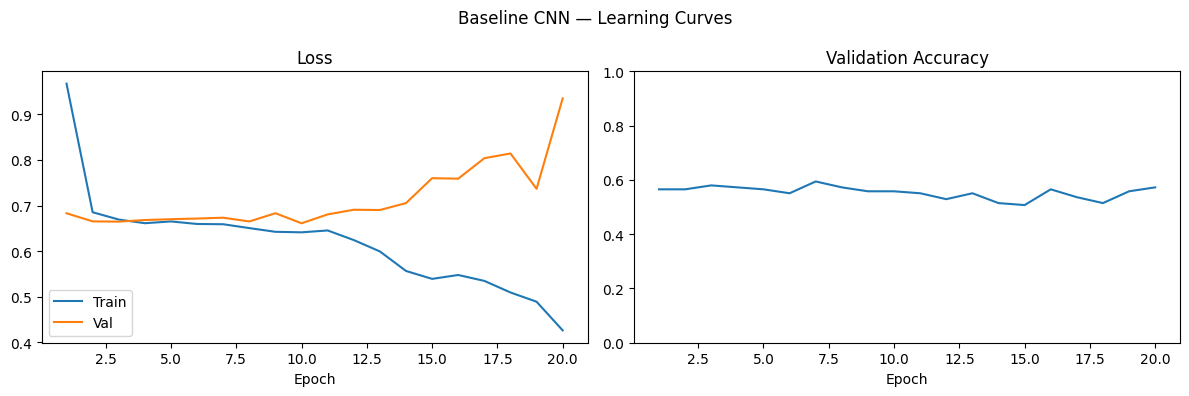

In [56]:
epochs = range(1, N_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history["train_loss"], label="Train")
ax1.plot(epochs, history["val_loss"],   label="Val")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(epochs, history["val_acc"])
ax2.set_title("Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylim(0, 1)

plt.suptitle("Baseline CNN — Learning Curves")
plt.tight_layout()
plt.show()

## Step 9 — Evaluate on the test set

We evaluate on the held-out test set exactly once.
These numbers are the official baseline metrics everything else will be compared against.

**Metrics:**
- **Accuracy** — overall correctness
- **Precision** — of predicted disease cases, how many were actually disease
- **Recall** — of actual disease cases, how many did we catch (most important in clinical settings)
- **F1** — harmonic mean of precision and recall
- **ROC-AUC** — overall discriminative ability across all thresholds

In [57]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

model.eval()
all_labels = []
all_preds  = []
all_probs  = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        probs   = torch.sigmoid(outputs).cpu().numpy()
        preds   = (probs >= 0.5).astype(int)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall    = recall_score(all_labels, all_preds, zero_division=0)
f1        = f1_score(all_labels, all_preds, zero_division=0)
roc_auc   = roc_auc_score(all_labels, all_probs)

print("=" * 35)
print("  BASELINE CNN — TEST RESULTS")
print("=" * 35)
print(f"  Accuracy:  {accuracy:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall:    {recall:.3f}")
print(f"  F1:        {f1:.3f}")
print(f"  ROC-AUC:   {roc_auc:.3f}")
print("=" * 35)

  BASELINE CNN — TEST RESULTS
  Accuracy:  0.511
  Precision: 0.340
  Recall:    0.567
  F1:        0.425
  ROC-AUC:   0.561


## Step 10 — Confusion matrix and ROC curve

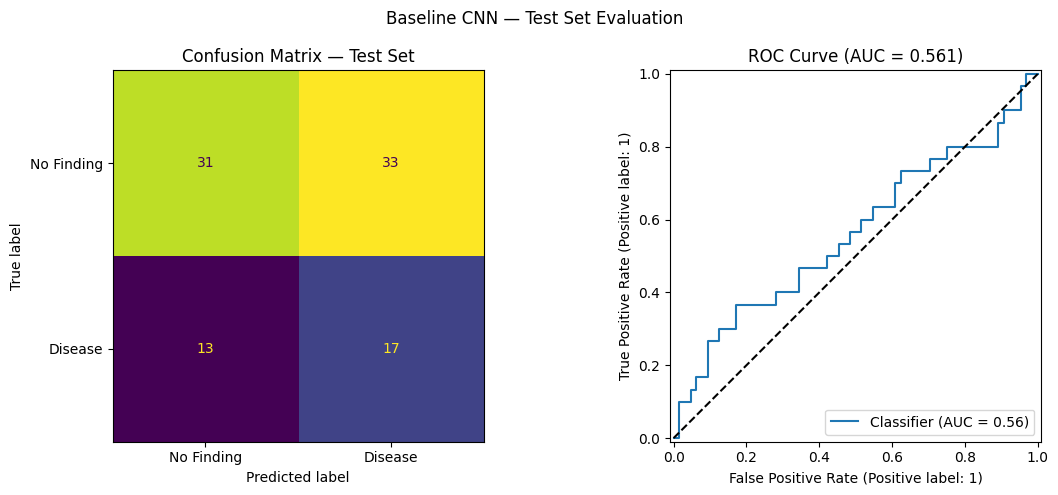

: 

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=["No Finding", "Disease"]).plot(ax=ax1, colorbar=False)
ax1.set_title("Confusion Matrix — Test Set")

# ROC curve
RocCurveDisplay.from_predictions(all_labels, all_probs, ax=ax2)
ax2.set_title(f"ROC Curve (AUC = {roc_auc:.3f})")
ax2.plot([0, 1], [0, 1], 'k--', label="Random")

plt.suptitle("Baseline CNN — Test Set Evaluation")
plt.tight_layout()
plt.show()

### Why our results are limited:

The baseline CNN trained from scratch on a small subset of images (527–1,000 training       
examples) consistently produced ROC-AUC scores in the 0.56–0.61 range, only marginally
better than random chance (0.50).                                                           
                                                                  
Two factors explain this:                                                                   
   
  - Architecture. A 3-layer CNN lacks the depth and capacity to detect the subtle visual        
  patterns that distinguish chest disease from healthy tissue — faint infiltrates, slight
  density changes, early-stage nodules. These features require much deeper networks to learn  
  reliably.                                                       

  - Data. Learning from scratch on fewer than 1,000 images is insufficient for any architecture.
  The model memorized training examples rather than learning generalizable features, as
  evidenced by training loss dropping sharply while validation loss rose — a clear sign of    
  overfitting.                                                    

The small test set (94 images, ~30 positive cases) also makes the AUC estimate noisy,       
  meaning small variations in which images land in the test set can swing the number by ±0.05
  without reflecting any real difference in model quality.                                    